# Pneumonia classification with ResNet18

Компанія **MediScan AI** впроваджує модель, яка за рентген-знімками грудної клітки визначає наявність пневмонії.

Потрібно підготувати датасет **Chest X-Ray Pneumonia**, навчити `ResNet18` через transfer learning, оцінити метрики й зберегти результати.

## Що потрібно отримати в кінці

1. Навчену модель `pneumonia_resnet18.pth`.
2. Графік з 8 тестовими прикладами `pneumonia_predictions.png`.
3. Метрики `Accuracy`, `Precision`, `Recall`, `F1-score` і confusion matrix.
4. Короткий висновок про готовність моделі до впровадження.


## 0. Імпорти та налаштування

Запустіть цю клітинку першою. За потреби встановіть бібліотеки з першого закоментованого рядка.


In [1]:
# Якщо потрібно, встановіть бібліотеки:
# pip install torch torchvision scikit-learn matplotlib pandas kagglehub

from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

RANDOM_STATE = 42
IMG_SIZE = 224
BATCH_SIZE = 32
N_EPOCHS = 5
LEARNING_RATE = 0.0001

MODEL_PATH = "pneumonia_resnet18.pth"
PREDICTIONS_PLOT_PATH = "pneumonia_predictions.png"

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)


PyTorch version: 2.12.1
Device: mps


## 1. Підготовка датасету

Потрібен датасет **Chest X-Ray Pneumonia** у структурі папок, сумісній з `ImageFolder`:

```text
data/chest_xray/
  train/
    NORMAL/
    PNEUMONIA/
  test/
    NORMAL/
    PNEUMONIA/
```

Можна завантажити датасет вручну або через Kaggle/KaggleHub. Після завантаження перевірте, що `DATA_ROOT` вказує саме на папку `chest_xray`.


In [2]:
DATA_ROOT = Path("data/chest_xray")

# Варіант для KaggleHub. Розкоментуйте, якщо хочете завантажити датасет автоматично.
# import kagglehub
# downloaded_path = Path(kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia"))
# DATA_ROOT = downloaded_path / "chest_xray"

print("DATA_ROOT:", DATA_ROOT.resolve())

expected_dirs = [
    DATA_ROOT / "train" / "NORMAL",
    DATA_ROOT / "train" / "PNEUMONIA",
    DATA_ROOT / "test" / "NORMAL",
    DATA_ROOT / "test" / "PNEUMONIA",
]

for folder in expected_dirs:
    status = "OK" if folder.exists() else "not found"
    print(f"{status:9} {folder}")


DATA_ROOT: /Users/dmitrostefan/Edu/python-ai-2026/заняття_12/data/chest_xray
not found data/chest_xray/train/NORMAL
not found data/chest_xray/train/PNEUMONIA
not found data/chest_xray/test/NORMAL
not found data/chest_xray/test/PNEUMONIA


### 1.1. Transforms, resize, normalization і DataLoader


In [3]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=7),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = None
test_dataset = None
train_loader = None
test_loader = None
class_names = None

if DATA_ROOT.exists():
    train_dataset = datasets.ImageFolder(DATA_ROOT / "train", transform=train_transform)
    test_dataset = datasets.ImageFolder(DATA_ROOT / "test", transform=test_transform)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

    class_names = train_dataset.classes
    print("Classes:", class_names)
    print("class_to_idx:", train_dataset.class_to_idx)
    print("Train images:", len(train_dataset))
    print("Test images:", len(test_dataset))
else:
    print("TODO: завантажте датасет і виставте правильний DATA_ROOT.")

TODO: завантажте датасет і виставте правильний DATA_ROOT.


### 1.2. Баланс класів

Порахуйте, скільки зображень кожного класу є у train/test. Для медичних задач дисбаланс класів може сильно впливати на `Precision` і `Recall`.


In [4]:
def dataset_class_counts(dataset):
    labels = [label for _, label in dataset.samples]
    counts = pd.Series(labels).value_counts().sort_index()
    return pd.DataFrame({
        "class": [dataset.classes[i] for i in counts.index],
        "count": counts.values,
        "share": (counts.values / counts.values.sum()).round(3),
    })


# TODO: перевірте кількість і частку класів у train_dataset.
# TODO: перевірте кількість і частку класів у test_dataset.


### 1.3. Перевірка batch

Перед навчанням переконайтеся, що `DataLoader` повертає тензори форми `(batch, 3, 224, 224)`.


In [5]:
def denormalize_image(image_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    image = image_tensor.cpu() * std + mean
    return torch.clamp(image, 0, 1)

if train_loader is not None:
    images, labels = next(iter(train_loader))
    print("Images shape:", tuple(images.shape))
    print("Labels shape:", tuple(labels.shape))
    print("First labels:", [class_names[i] for i in labels[:8].tolist()])

    plt.figure(figsize=(10, 4))
    for i in range(min(8, len(images))):
        plt.subplot(2, 4, i + 1)
        image = denormalize_image(images[i]).permute(1, 2, 0).numpy()
        plt.imshow(image)
        plt.title(class_names[labels[i].item()])
        plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Спочатку створіть train_loader.")


Спочатку створіть train_loader.


## 2. ResNet18 для класифікації пневмонії

Використайте переднавчену `ResNet18`, заморозьте згорткову частину й замініть classification head на `Linear(512, 2)`.


In [6]:
# TODO: завантажте pretrained ResNet18.
model = None

# TODO: заморозьте згорткові шари моделі.

# TODO: замініть classification head на nn.Linear(512, 2).

# TODO: створіть CrossEntropyLoss.
loss_fn = None

# TODO: створіть Adam optimizer з lr=0.0001.
# В optimizer передайте тільки параметри нового класифікатора.
optimizer = None

model


### 2.1. Train loop

Навчіть модель протягом `5` епох. У train loop потрібно виконати forward pass, loss, backward pass і optimizer step. Для test set використовуйте `torch.no_grad()`.


In [7]:
def train_one_epoch(model, loader, loss_fn, optimizer, device):
    # TODO: реалізуйте одну епоху навчання.
    # Поверніть середній loss і accuracy за епоху.
    pass


def evaluate_loss_accuracy(model, loader, loss_fn, device):
    # TODO: реалізуйте оцінювання без оновлення ваг.
    # Поверніть середній loss і accuracy.
    pass


In [8]:
history = []

# TODO: запустіть навчання на N_EPOCHS епох.
# Для кожної епохи збережіть train_loss, train_acc, test_loss, test_acc у history.
# Після навчання створіть history_df = pd.DataFrame(history).

# history_df


### 2.2. Графік навчання

Будуємо графіки `Loss` і `Accuracy` для train/test. Подивіться, чи не зростає test loss і чи не є різниця між train/test accuracy надто великою.


NameError: name 'history_df' is not defined

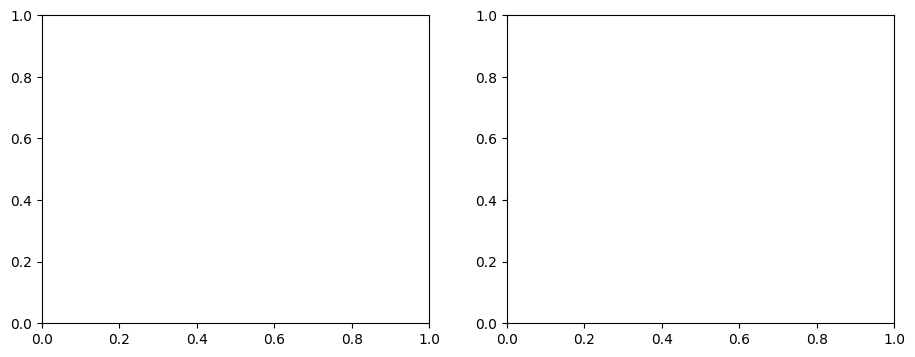

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train")
axes[0].plot(history_df["epoch"], history_df["test_loss"], label="test")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_acc"], label="train")
axes[1].plot(history_df["epoch"], history_df["test_acc"], label="test")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Оцінка якості

Рахуємо `Accuracy`, `Precision`, `Recall` і `F1-score`. Для медичної задачі окремо зверніть увагу на `Recall` для класу `PNEUMONIA`: пропущені випадки пневмонії можуть бути критичними.


In [ ]:
def collect_predictions(model, loader, device):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            logits = model(images)
            predictions = logits.argmax(dim=1).cpu().numpy()

            y_true.extend(labels.numpy().tolist())
            y_pred.extend(predictions.tolist())

    return np.array(y_true), np.array(y_pred)


y_true, y_pred = collect_predictions(model, test_loader, device)

positive_label = next(
    (idx for name, idx in train_dataset.class_to_idx.items() if name.lower() == "pneumonia"),
    1,
)

metrics = {
    "accuracy": accuracy_score(y_true, y_pred),
    "precision": precision_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
    "recall": recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
    "f1_score": f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
}

pd.DataFrame([metrics]).round(4)

In [ ]:
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
display_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

display_cm.plot(cmap="Blues", values_format="d")
plt.title("Confusion matrix: ResNet18 pneumonia classifier")
plt.show()

### 3.1. Збереження моделі

Зберігаємо навчену модель у файл `pneumonia_resnet18.pth`. Не лише ваги, а й `class_to_idx`, щоб пізніше правильно інтерпретувати класи.


In [ ]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "class_to_idx": train_dataset.class_to_idx,
        "image_size": IMG_SIZE,
        "model_name": "resnet18",
    },
    MODEL_PATH,
)

print(f"Model saved to: {MODEL_PATH}")


## 4. Візуалізація результатів

Показуємо `8` випадкових зображень із test set. У заголовку кожного зображення має бути реальний і передбачений клас. Зберігаємо графік у файл `pneumonia_predictions.png`.


In [ ]:
def show_random_predictions(model, dataset, class_names, device, n_images=8, save_path=PREDICTIONS_PLOT_PATH):
    model.eval()
    n_images = min(n_images, len(dataset))
    indices = random.sample(range(len(dataset)), k=n_images)

    fig, axes = plt.subplots(2, 4, figsize=(13, 7))
    axes = axes.ravel()

    with torch.no_grad():
        for ax, idx in zip(axes, indices):
            image_tensor, true_label = dataset[idx]
            logits = model(image_tensor.unsqueeze(0).to(device))
            pred_label = logits.argmax(dim=1).item()

            image = denormalize_image(image_tensor).permute(1, 2, 0).numpy()
            ax.imshow(image)
            ax.axis("off")

            color = "darkgreen" if pred_label == true_label else "darkred"
            ax.set_title(
                f"""pred: {class_names[pred_label]}, true: {class_names[true_label]}""",
                color=color,
                fontsize=10,
            )

    for ax in axes[n_images:]:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"Predictions plot saved to: {save_path}")


show_random_predictions(model, test_dataset, class_names, device)

## 5. Висновок

Напишіть короткий висновок українською мовою.

Орієнтири для висновку:

- Які значення `Accuracy`, `Precision`, `Recall`, `F1-score` отримала модель?
- Чи достатній `Recall` для класу `PNEUMONIA`?
- Які помилки видно у confusion matrix?
- Чому це навчальний прототип, а не готова медична система?


**Ваш висновок:**

> TODO: напишіть 4-6 речень про якість моделі, обмеження датасету й готовність до впровадження.
